In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv("united_customer_journey_RCA.csv")

In [4]:
df.head(3)

,customer_id,flight_id,checkin_wait_min,baggage_wait_min,inflight_service_rating,issue_checkin,issue_baggage,issue_inflight,nps_score,total_issues
0,1,17270,36,19,2,0,0,0,7,0
1,2,10860,2,11,4,0,1,0,0,1
2,3,15390,22,4,4,0,1,0,5,1


In [6]:
# Remove duplicates
df = df.drop_duplicates()

In [9]:
# For missing values
df = df.fillna({
    "checkin_wait_min": df.checkin_wait_min.median(),
    "baggage_wait_min": df.baggage_wait_min.median(),
    "inflight_service_rating": df.inflight_service_rating.median()
})

In [12]:
df["checkin_buckett"] = pd.cut(df.checkin_wait_min, bins=[0,10,20,40,100],
                              labels=["Fast","Moderate","Slow","Severe"])

df["baggage_bucket"] = pd.cut(df.baggage_wait_min, bins=[0,10,20,40,100],
                               labels=["Fast","Moderate","Slow","Severe"])

In [13]:
issue_summary = df.groupby("total_issues")[["nps_score"]].mean()
print(issue_summary)

              nps_score
total_issues           
0              6.390146
1              6.377778
2              6.304498
3              6.055556


In [17]:
stage_rca = {
    "Check-in Issues": df[df.issue_checkin==1].nps_score.mean(),
    "Baggage Issues": df[df.issue_baggage==1].nps_score.mean(),
    "Inflight Issues": df[df.issue_inflight==1].nps_score.mean()
}

stage_rca

{'Check-in Issues': np.float64(6.363896848137536),
 'Baggage Issues': np.float64(6.259428571428572),
 'Inflight Issues': np.float64(6.484969939879759)}

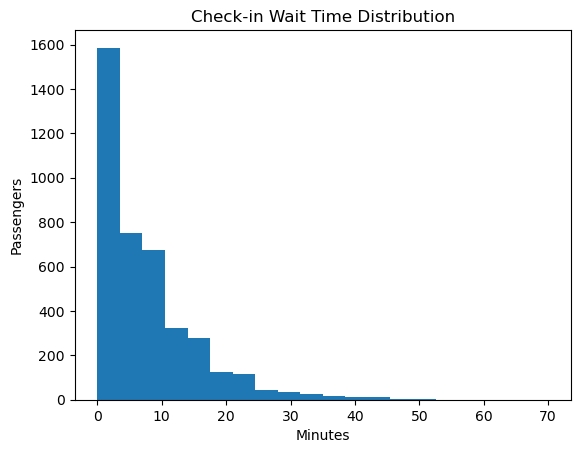

In [20]:
plt.hist(df.checkin_wait_min, bins=20)
plt.title("Check-in Wait Time Distribution")
plt.xlabel("Minutes")
plt.ylabel("Passengers")
plt.show()

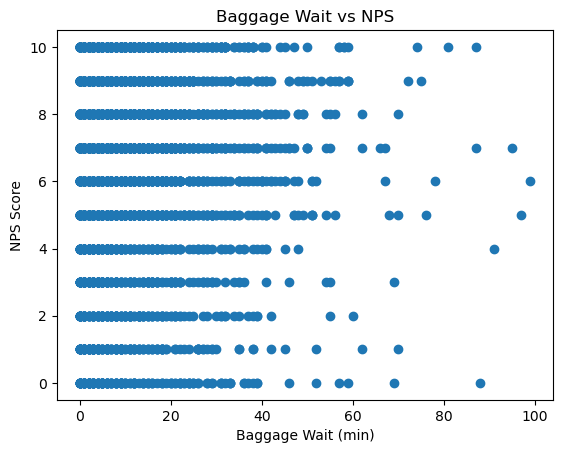

In [21]:
plt.scatter(df.baggage_wait_min, df.nps_score)
plt.title("Baggage Wait vs NPS")
plt.xlabel("Baggage Wait (min)")
plt.ylabel("NPS Score")
plt.show()